# What the contracts buy you

> You will see two unrelated classes pass the same raptor check, just by
> having the right methods.

**Time:** ~5 min · **Runs on:** CPU, no GPU needed · **You need:** nothing
beyond raptor itself.


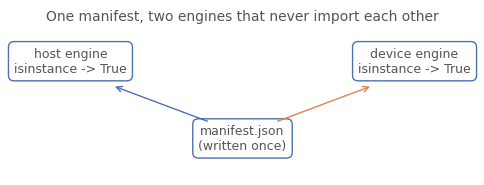

In [1]:
import sys; sys.path.insert(0, "../_shared")
from nb_diagrams import two_engines_diagram
two_engines_diagram()


## The code

A `typing.Protocol` is a list of required methods: Python checks an object
against it with `isinstance`, by shape alone, never by whether it inherits
from anything. Below, two **engines** (an engine = the object that
actually runs a kernel) each implement the same shape; the methods beyond
what gets called exist only to complete that shape, so their return
values do not matter here:

First engine. `ToyHostEngine` implements `KernelLauncher` + `Backend`
(both explained below) by shape alone — no inheritance, no shared base
class:

In [2]:
class ToyHostEngine:
    name = "host"
    def launch(self, *a, **kw): return "ran on CPU threads"
    def assemble_args(self, *a, **kw): return ()
    def pure_origin(self, *a, **kw): return "numpy"
    def pure_prepare(self, *a, **kw): return ()
    def capabilities(self): return frozenset({"forward"})
    def compile(self, program): return program

print(ToyHostEngine().launch())


ran on CPU threads


Just a plain class — nothing about it mentions `raptor` yet.


A second, independent engine with the same shape. `ToyDeviceEngine` never
imports `ToyHostEngine`, and neither one imports raptor's own runtime:


In [3]:
class ToyDeviceEngine:
    name = "device"
    def launch(self, *a, **kw): return "ran on the GPU"
    def assemble_args(self, *a, **kw): return ()
    def pure_origin(self, *a, **kw): return "cupy"
    def pure_prepare(self, *a, **kw): return ()
    def capabilities(self): return frozenset({"forward"})
    def compile(self, program): return program

print(ToyDeviceEngine().launch())


ran on the GPU


Also just a plain class — the two have not heard of each other.


Now check both against **`KernelLauncher`** (the four methods a launcher
needs) and **`Backend`** (the two more a backend needs) with `isinstance` —
the same runtime check a real caller such as eagle would make. The other
five methods on each class above exist only to complete that shape, so
their return values never mattered:

In [4]:
from raptor.protocols import Backend, KernelLauncher

for engine in (ToyHostEngine(), ToyDeviceEngine()):
    ok = isinstance(engine, KernelLauncher) and isinstance(engine, Backend)
    print(f"{engine.name:>6}: KernelLauncher+Backend={ok}")


  host: KernelLauncher+Backend=True
device: KernelLauncher+Backend=True


Both report `True` — the protocol checked their shape, never their ancestry.


## What just happened

- `KernelLauncher` and `Backend` are `typing.Protocol`s: an object satisfies
  them by having the right methods, checked at runtime with `isinstance`,
  never by inheriting from a shared base class.
- The two toy engines above never import each other, yet both pass the
  exact same checks a real engine such as eagle would.
- A compiled kernel ships with a small manifest describing it — covered
  next — but running one needs an engine shaped like these first.

## Try this

Rename `launch` to `run` on `ToyDeviceEngine` and re-run the loop:
`isinstance(..., KernelLauncher)` drops to `False` — the protocol checks
names, not intentions.

## Next

[Write a manifest](02_write_a_manifest) covers the document a compiler such
as hawk writes once, and that an engine like these would read. Deeper:
[Concepts](/content/concepts).
